In [ ]:
# 데이터 동일
# 모델도 동일
# 옵티마이저는 momentum을 사용해서

모멘텀

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 시드 고정 (재현성)
np.random.seed(42)
torch.manual_seed(42)

In [2]:
X_clf, y_clf = make_classification(
    n_samples=400, n_features=2, random_state=42,
    n_informative=2, n_redundant=0,n_clusters_per_class=1,class_sep=1.5
    )
scaler = StandardScaler()
# 데이터 분할 train - test 8:2
x_train,x_test,y_train,y_test = train_test_split(X_clf,y_clf,random_state=42, stratify=y_clf,test_size=0.2)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
# pytorch 텐서로 변환
X_clf_train_tensor = torch.tensor(x_train,dtype=torch.float32)
y_clf_train_tensor = torch.FloatTensor(y_train)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.FloatTensor(y_test)

In [3]:
# 분류모델 정의
class BinaryClassifier(nn.Module):
  def __init__(self,input_dim, hidden_dim) -> None:
    super().__init__()
    self.fc1 = nn.Linear( input_dim , hidden_dim)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_dim ,1 )
  def forward(self, x):
    x = self.relu( self.fc1(x) )
    output = self.fc2(x)
    return output
model_clf = BinaryClassifier(2,16)
model_clf     

BinaryClassifier(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

100%|██████████| 100/100 [00:00<00:00, 103.03it/s]


[13.031733393669128,
 9.496597677469254,
 6.592970564961433,
 4.646374851465225,
 3.58206944167614,
 3.0274864211678505,
 2.7065937891602516,
 2.5166757106781006,
 2.3898144718259573,
 2.30299049988389,
 2.226844247430563,
 2.1602022275328636,
 2.1257974840700626,
 2.089298328384757,
 2.0515952799469233,
 2.0277762934565544,
 2.0049246111884713,
 1.989293022081256,
 1.9680538699030876,
 1.968090116046369,
 1.9552329173311591,
 1.930540825240314,
 1.9255373105406761,
 1.9138884218409657,
 1.9017279222607613,
 1.9032326661981642,
 1.8893127543851733,
 1.89599784091115,
 1.8779274942353368,
 1.8873803168535233,
 1.8718397775664926,
 1.8793167946860194,
 1.8622415298596025,
 1.8590196571312845,
 1.863089878577739,
 1.8491166941821575,
 1.8954175980761647,
 1.8804317880421877,
 1.8647836628369987,
 1.8582592159509659,
 1.8385983938351274,
 1.8395787430927157,
 1.8830056870356202,
 1.8262125747278333,
 1.8346862029284239,
 1.8462081719189882,
 1.8431921107694507,
 1.8280397402122617,
 1.8236

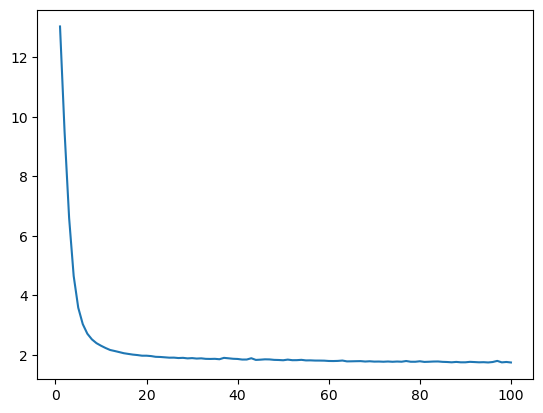

In [6]:
from tqdm import tqdm
model_clf = BinaryClassifier(2,16)
criterion = nn.BCEWithLogitsLoss()
optimizer_momentum = optim.SGD(model_clf.parameters(), lr=0.01, momentum=0.9)

x_train_dataset = TensorDataset(X_clf_train_tensor,y_clf_train_tensor)
x_train_loader = DataLoader(x_train_dataset,batch_size=16,shuffle=True)
# 훈련루프
epochs = 100
epoch_losses = []
for epoch in tqdm(range(epochs)):
  epoch_loss = 0
  for data, label in x_train_loader:
    optimizer_momentum.zero_grad();
    predict = model_clf(data).squeeze(1)
    loss = criterion(predict, label)
    loss.backward()
    optimizer_momentum.step()
    epoch_loss +=  loss.item()
  epoch_loss / len(x_train_loader)
  epoch_losses.append(epoch_loss)

# loss값들을 저장해서 시각화 vs sgd
plt.plot(range(1,epochs+1),epoch_losses )
epoch_losses
